[![Colabで開く](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/schwalbe1996/ds_media_intro/blob/main/chap11_ex.ipynb)

# 11章 演習問題（宿題）：自分だけのカラーフィルタで画像を加工しよう

このノートブックは 11 章「画像データの概要」の宿題です。所要時間は20分程度です。

このノートブックには **コードの一部しか書かれていません**。`chap11.ipynb` を開いて見ながら、`# TODO` の部分を**自分で埋めて**完成させましょう。「どのセルのコードが使えそうか」を探すことも勉強のうちです。

## 課題A. 自分だけのカラーフィルタを作る
`chap11.ipynb` の **「セピア変換」のセル**（`newR = 0.393*R + ...` のセル）を参考にコードを書き、**係数を自分で変えて**オリジナルの色フィルタを作りましょう。
- R・G・B の係数や組み合わせを変えるだけで構いません。
- 例: 青を強調する／特定のチャンネルを 0 にする／全体を青みや赤みに振る、など。

**観察と考察:** このノートブックでは、255 を超える値を 255 に直した **クリップあり版（`filtered`）** と、直さない **クリップなし版（`filtered_overflow`）** の両方を作って見比べます。
- 問い: クリップなし版はなぜ色が壊れて変なまだら模様になるのでしょう？「画像は uint8（0〜255 しか表せない整数）で保存されている」ことと結びつけて、1〜2行で説明してください（提出セルの `answer_A` に記入します）。

## 課題B. フィルタを画像の一部だけにかける
`chap11.ipynb` の **「切り出し・マスク」のセル**（`image[130:200,150:250]` などが出てくるセル）を参考に、課題Aで作ったフィルタ（`filtered`）を **画像の一部の矩形領域だけ** に適用し、残りは元画像のままにしましょう。

## 提出方法（重要）
最後の **「提出ファイルの作成」セル** を実行すると、3枚の結果画像と考察を1枚にまとめた PDF が自動で作られ、ダウンロードされます。
- ファイル名は **`学籍番号_フルネーム_11.pdf`** になります。氏名は**ローマ字・名+姓・スペースなし**で書きます（例: 彦根太郎 → `TaroHikone`、ファイル名 → `5025123_TaroHikone_11.pdf`）。提出セルの `student_id` と `student_name` を**自分のものに書き換えてから**実行してください。
- 提出するのはこの **PDF 1ファイルだけ** です。

In [2]:
# 画像のダウンロードとライブラリの読み込み（このセルはそのまま実行）
!wget -nc https://github.com/schwalbe1996/ds_media_intro/raw/main/sample.png
!pip install -q japanize-matplotlib setuptools  # setuptools は japanize の依存(distutils)対策

import cv2
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib  # PDF内の日本語を表示するため

File ‘sample.png’ already there; not retrieving.



In [3]:
!pip install -q japanize-matplotlib setuptools  # setuptools は japanize の依存(distutils)対策

import cv2
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

## 課題A：自作カラーフィルタ

`chap11.ipynb` の「セピア変換」のセルを参考に、`# TODO` を埋めよう。

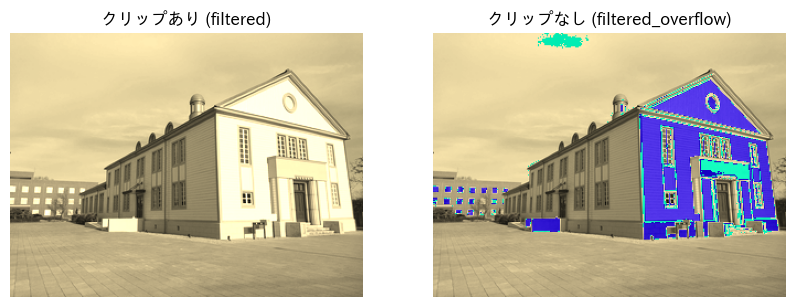

In [4]:
img = cv2.imread('sample.png')

# TODO: img から B, G, R の各チャンネルを取り出す（chap11 のセピアのセルを参考に）
B = img[:,:,0]
G = img[:,:,1]
R = img[:,:,2]

# TODO: 係数を自分で決めて newR, newG, newB を計算する（セピアの係数を変えてみよう）

newR = 0.786*R + 0.384*G + 0.378*B
newG = 0.696*R + 0.343*G + 0.378*B
newB = 0.544*R + 0.267*G + 0.262*B

# TODO: cv2.merge を使って1枚の画像にまとめ、filtered_raw という変数に入れる
#       （この時点ではまだ float のまま。uint8 変換は下で行う）

filtered_raw = cv2.merge([newB, newG, newR])

# === ここから下はそのまま実行 ===
# クリップなし版：255 を超えた値がそのまま uint8 になる（オーバーフローで壊れる）
filtered_overflow = filtered_raw.astype(np.uint8)

# クリップあり版：255 を超える値を 255 に直してから uint8 にする
filtered = filtered_raw.copy()
filtered[filtered > 255] = 255
filtered = filtered.astype(np.uint8)

# 2つを見比べる
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB)); plt.title('クリップあり (filtered)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(filtered_overflow, cv2.COLOR_BGR2RGB)); plt.title('クリップなし (filtered_overflow)'); plt.axis('off')
plt.show()

## 課題B：一部の領域だけにフィルタを適用

`chap11.ipynb` の「切り出し・マスク」のセル（`image[130:200,150:250]` など）を参考に、`# TODO` を埋めよう。

(240, 320, 3)

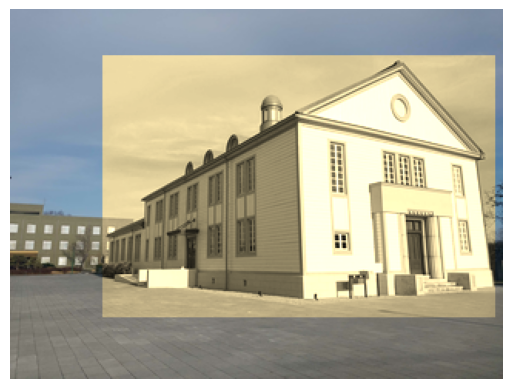

In [15]:
# TODO: 元画像を壊さないよう、img をコピーして result を作る（.copy() を使う）

result = img.copy()

# TODO: img の高さ・幅を取得する（image.shape を参考に）

shape = img.shape

# TODO: フィルタをかける矩形領域の範囲 y1, y2, x1, x2 を決める

y1 = img.shape[0]//2 - 90
y2 = img.shape[0]//2 + 80
x1 = img.shape[1]//2 - 100
x2 = img.shape[1]//2 + 155

# TODO: result の指定領域に、filtered の同じ領域を代入する
#       （例の形：result[y1:y2, x1:x2] = ... ）

result[y1:y2, x1:x2] = filtered[y1:y2, x1:x2]

# できあがった result を表示
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 提出ファイルの作成

下の `student_id`・`student_name`・`answer_A` を書き換えてから実行すると、提出用 PDF が作られてダウンロードされます。**この PDF 1ファイルだけ** を提出してください。

In [ ]:
import matplotlib.gridspec as gridspec

# ★ 自分の情報に書き換える ★
student_id   = "5025195"             # 学籍番号（7桁）
student_name = "YutoNakamoto"          # フルネーム（ローマ字・名+姓・スペースなし。例: 彦根太郎→TaroHikone）
# 考察は下の """ と """ の間に書く（改行して複数行でも、長い一文でもよい。自動で折り返される）
answer_A = """倍率が高いと、数値がオーバーフローしてしまうから。"""

# === ここから下はそのまま実行 ===
def wrap_jp(text, width=42):
    """日本語は空白がなく自動折り返しが効かないため、width文字ごとに改行を入れる（明示的な改行は保持）"""
    out = []
    for para in text.split("\n"):
        if para == "":
            out.append("")
        else:
            out += [para[i:i+width] for i in range(0, len(para), width)]
    return "\n".join(out)

fig = plt.figure(figsize=(8.27, 11.69))  # A4縦
gs = gridspec.GridSpec(3, 2, height_ratios=[1.2, 1.2, 1])
fig.suptitle(f"{student_id} {student_name}　マルチメディア処理入門 宿題11", fontsize=14)

ax1 = fig.add_subplot(gs[0, :])
ax1.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
ax1.set_title("1. 自作フィルタ（全体）"); ax1.axis('off')

ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(cv2.cvtColor(filtered_overflow, cv2.COLOR_BGR2RGB))
ax2.set_title("2. クリップなし（オーバーフロー）"); ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
ax3.set_title("3. 一部領域だけにフィルタ"); ax3.axis('off')

ax4 = fig.add_subplot(gs[2, :]); ax4.axis('off')
ax4.text(0.01, 0.99, "【課題Aの考察】\n" + wrap_jp(answer_A), va='top', ha='left', fontsize=11)

filename = f"{student_id}_{student_name}_11.pdf"
fig.savefig(filename, bbox_inches='tight')
plt.show()
print("保存しました:", filename)

# Colab なら自動でダウンロード
try:
    from google.colab import files
    files.download(filename)
except Exception:
    print("（Colab 以外では自動ダウンロードされません。左のファイル一覧から取得してください）")